In [229]:
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib.pyplot as plt
import casadi as ca

In [230]:
def headloss_pipes(
    inductance: float | npt.NDArray,
    resistance: float | npt.NDArray,
    volume_flow: float | npt.NDArray,
) -> float | npt.NDArray:
    if not (inductance.shape == resistance.shape == volume_flow.shape):
        raise ValueError("Input values not of the same shape.")
    with np.errstate(divide="raise", invalid="raise"):
        return (resistance / inductance) * abs(volume_flow) * volume_flow

## General constants

In [231]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

In [232]:
## average operating conditions
# volume flow
q_mean = 0.0001  # 0224331792911098  # m^3/2
# pump speed
omega_mean = 36.410179219931635  # 35.35520636739956  # 9.7996642  # Hz
omega_max = 74.166667
omega_mean_relative = omega_mean / 74.166667  # dimensionless
mean_pump_pressure = 25274.0257666655

## Network elements

In [233]:
internal_nodes = {
    "pump_inlet": {
        "name": "pump_inlet",
        "node_type": "Junction",
        "elevation": 0.33,
        "demand": 0,
    },
    "pump_outlet": {
        "name": "pump_outlet",
        "node_type": "Junction",
        "elevation": 0.47,
        "demand": 0,
    },
    "tank_inlet": {
        "name": "tank_inlet",
        "node_type": "Tank",
        "elevation": 2.12,
        "area": 1e3,
        "initial_level": 0.0,
        "max_level": 100,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "tank_outlet": {
        "name": "tank_outlet",
        "node_type": "Tank",
        "elevation": 1.2,
        "area": 0.03,  # guess
        "initial_level": 0.2,
        "max_level": 1,
        "demand": 0.000,  # 0.0001 # 0224331792911098
    },
    "consumer_valve_inlet": {
        "name": "consumer_valve_inlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
    "consumer_valve_outlet": {
        "name": "consumer_valve_outlet",
        "node_type": "Junction",
        "elevation": 0.875,
        "demand": 0,
    },
}

In [234]:
reservoirs = {
    "reservoir_1": {
        "name": "reservoir_1",
        "elevation": 0.56,
        "pressure": 0.3833,
    },
    "reservoir_2": {
        "name": "reservoir_2",
        "elevation": 0.56,
        "pressure": 0.3833,
    },
}

In [235]:
pipes = {
    "pump_suction_pipe": {
        "start_node": "reservoir_1",
        "end_node": "pump_inlet",
        "type": "pipe",
        "length": 2.25,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    "tank_feeding_pipe": {
        "start_node": "pump_outlet",
        "end_node": "tank_inlet",
        "type": "pipe",
        "length": 5,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
    "tank_connecting_pipe": {
        "start_node": "tank_inlet",
        "end_node": "tank_outlet",
        "type": "pipe",
        "length": 1,
        "diameter": 0.015,
        "roughness": 0.07,  # 0.007e-3,
        "friction_factor": 4.4,  # 4.4e-3,  # 1.1357142e-1,
    },
    "tank_outlet_pipe": {
        "start_node": "tank_outlet",
        "end_node": "consumer_valve_inlet",
        "type": "pipe",
        "length": 1.7,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 3.383e-3,  # 2.65e-1,
    },
    "valve_pipe": {
        "start_node": "consumer_valve_inlet",
        "end_node": "consumer_valve_outlet",
        "type": "pipe",
        "length": 0.1,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 1.65e-3,  # 1.325e-1,  # 0.021
    },
    "consumer_outlet_pipe": {
        "start_node": "consumer_valve_outlet",
        "end_node": "reservoir_2",
        "type": "pipe",
        "length": 0.35,
        "diameter": 0.015,
        "roughness": 0.007e-3,
        "friction_factor": 4.4e-3,  # 1.1357142e-1,
    },
}

In [236]:
elements = {
    "pump": {
        "start_node": "pump_inlet",
        "end_node": "pump_outlet",
        "type": "pump",
        "diameter": 0.015,
        "length": 0.1,
        "head_coefficients": [-0.1045223, 0.18435539, 10.63028341],
        "power_coefficients": [
            -3.24482049,
            7.30651404,
            20.33482845,
            103.00866719,
            7.59352180888483,
        ],
        "system_coefficent": 0.3,  # 0.2,
        "min_speed": 23.33333,
        "max_speed": 74.16667,
        "initial_input": omega_mean,  # 35.35520636739956,
    },
}

## Definition of matrices

In [237]:
pipe_number = len(pipes.keys())
internal_node_number = len(internal_nodes.keys())
reservoir_number = len(reservoirs.keys())
element_number = len(elements.keys())

In [238]:
for name, properties in elements.items():
    properties["cross_section_area"] = (properties["diameter"] / 2) ** 2 * np.pi
a_0 = elements["pump"]["cross_section_area"]
pump_coeffs = elements["pump"]["head_coefficients"]

In [239]:
for name, properties in pipes.items():
    properties["cross_section_area"] = (properties["diameter"] / 2) ** 2 * np.pi

In [240]:
inverse_relative_roughnesses = {}
for name, properties in pipes.items():
    inverse_relative_roughnesses[name] = (
        properties["diameter"] / properties["roughness"]
    )

In [241]:
initial_condition_flow_pipes = np.full((len(pipes.keys()), 1), q_mean)
initial_condition_flow_elements = np.full((len(elements.keys()), 1), q_mean)

In [242]:
edge_dict = {}
for name, edge in pipes.items():
    edge_dict[name] = (edge["start_node"], edge["end_node"])
for name, edge in elements.items():
    edge_dict[name] = (edge["start_node"], edge["end_node"])
graph_edge_list = [edge for edge in edge_dict.values()]

In [243]:
graph = nx.Graph()
graph.add_nodes_from(reservoirs.keys())
graph.add_nodes_from(internal_nodes.keys())
graph.add_edges_from(edge_dict.values())

In [244]:
internal_nodes_list = [name for name in internal_nodes.keys()]
reservoir_nodes_list = [name for name in reservoirs.keys()]
node_list = internal_nodes_list + reservoir_nodes_list

In [245]:
pipe_list = [name for name in pipes.keys()]
element_list = [name for name in elements.keys()]
edge_list = pipe_list + element_list

In [246]:
incidence_matrix = -nx.incidence_matrix(
    graph, oriented=True, nodelist=node_list, edgelist=graph_edge_list
)
print(incidence_matrix.todense())

[[-1.  0.  0.  0.  0.  0.  1.]
 [ 0.  1.  0.  0.  0.  0. -1.]
 [ 0. -1.  1.  0.  0.  0.  0.]
 [ 0.  0. -1.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  1.  0.  0.]
 [ 0.  0.  0.  0. -1.  1.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.]]


In [247]:
A_I = np.array(incidence_matrix.todense()[:internal_node_number])
A_R = np.array(incidence_matrix.todense()[-reservoir_number:])

In [248]:
A_I_p = A_I[:, :pipe_number]
A_I_e = A_I[:, -element_number:]
A_R_p = A_R[:, :pipe_number]
A_R_e = A_R[:, -element_number:]

In [249]:
inductance = []
resistance = []
capacitance = []
tank_capacitance = []
for properties in pipes.values():
    inductance.append(properties["length"] / (g * properties["cross_section_area"]))
    resistance.append(
        8
        * properties["length"]
        * properties["roughness"]
        / (np.pi**2 * g * properties["diameter"] ** 5)
    )
    capacitance.append(
        (2 * g * np.pi / 4 * properties["diameter"] ** 2 * properties["length"])
        / (a**2)
    )

for properties in internal_nodes.values():
    if properties["node_type"] == "Tank":
        tank_capacitance.append(properties["area"])
    else:
        tank_capacitance.append(0.0)

for properties in elements.values():
    capacitance.append(
        (2 * g * np.pi / 4 * properties["diameter"] ** 2 * properties["length"])
        / (a**2)
    )

In [250]:
system_coeffcients = []
for properties in elements.values():
    system_coeffcients.append(properties["system_coefficent"])

In [251]:
internal_nodes.keys()

dict_keys(['pump_inlet', 'pump_outlet', 'tank_inlet', 'tank_outlet', 'consumer_valve_inlet', 'consumer_valve_outlet'])

In [252]:
L = np.array(inductance).reshape(len(list(pipes.keys())), 1)
R = np.array(resistance).reshape(len(list(pipes.keys())), 1)
C = np.array(capacitance).reshape(
    len(list(pipes.keys())) + len(list(elements.keys())), 1
)
TC = np.array(tank_capacitance).reshape(len(list(internal_nodes.keys())), 1)

In [253]:
f_p_initial = headloss_pipes(L, R, initial_condition_flow_pipes)
f_p_initial

array([[1.32039656e-08],
       [1.32039656e-08],
       [1.32039656e-04],
       [1.32039656e-08],
       [1.32039656e-08],
       [1.32039656e-08]])

In [254]:
reservoir_total_head = (
    reservoirs["reservoir_1"]["pressure"] + (reservoirs["reservoir_1"]["elevation"])
)
reservoir_total_head

0.9433

In [255]:
internal_nodes["pump_inlet"]["initial_head"] = (
    0.9432828625777657  #  1.39962220  # (internal_nodes["consumer_valve_inlet"]["elevation"])  # internal_nodes["consumer_valve_outlet"]["initial_head"] + R[1,0] * q_mean**2 +
)
internal_nodes["pump_outlet"]["initial_head"] = (
    (25274.0257666655 / (rho * g)) + internal_nodes["pump_inlet"]["initial_head"]
)  # internal_nodes["pump_outlet"]["elevation"] #  1.39800676  # (internal_nodes["consumer_valve_outlet"]["elevation"])  # internal_nodes["consumer_outlet"]["initial_head"] + R[2,0] * q_mean**2 +
internal_nodes["tank_inlet"]["initial_head"] = (
    3.524243866935379
    - 0.2  #  1.39799373  # internal_nodes["consumer_outlet"]["elevation"]  # (1/(2*g))*(q_mean/pipes["consumer_outlet_pipe"]["cross_section_area"])**2
)

internal_nodes["tank_outlet"]["initial_head"] = (
    1.2  #  1.39799373  # internal_nodes["consumer_outlet"]["elevation"]  # (1/(2*g))*(q_mean/pipes["consumer_outlet_pipe"]["cross_section_area"])**2
)
internal_nodes["consumer_valve_inlet"]["initial_head"] = (
    0.875  #  1.39799373  # internal_nodes["consumer_outlet"]["elevation"]  # (1/(2*g))*(q_mean/pipes["consumer_outlet_pipe"]["cross_section_area"])**2
)
internal_nodes["consumer_valve_outlet"]["initial_head"] = (
    0.875  #  1.39799373  # internal_nodes["consumer_outlet"]["elevation"]  # (1/(2*g))*(q_mean/pipes["consumer_outlet_pipe"]["cross_section_area"])**2
)

In [256]:
(
    internal_nodes["pump_outlet"]["initial_head"]
    - internal_nodes["pump_inlet"]["initial_head"]
)

2.580999087518134

In [257]:
for name, properties in pipes.items():
    if (properties["start_node"] in internal_nodes.keys()) and (
        properties["end_node"] in internal_nodes.keys()
    ):
        properties["friction_factor"] = (
            internal_nodes[properties["start_node"]]["initial_head"]
            - internal_nodes[properties["end_node"]]["initial_head"]
        ) / (
            (properties["length"] / properties["diameter"])
            * (1 / (2 * g))
            * (q_mean / properties["cross_section_area"]) ** 2
        )

    elif properties["start_node"] not in internal_nodes.keys():
        properties["friction_factor"] = (
            reservoirs["reservoir_1"]["pressure"]
            + (reservoirs["reservoir_1"]["elevation"])
            - internal_nodes[properties["end_node"]]["initial_head"]
        ) / (
            (properties["length"] / properties["diameter"])
            * (1 / (2 * g))
            * (q_mean / properties["cross_section_area"]) ** 2
        )
    else:
        properties["friction_factor"] = (
            +internal_nodes[properties["start_node"]]["initial_head"]
            - reservoirs["reservoir_2"]["pressure"]
            + (reservoirs["reservoir_2"]["elevation"])
        ) / (
            (properties["length"] / properties["diameter"])
            * (1 / (2 * g))
            * (q_mean / properties["cross_section_area"]) ** 2
        )

    print(f"{name}: {properties['friction_factor']}")

pump_suction_pipe: 7.0000000000358235e-06
tank_feeding_pipe: 0.036768654780388876
tank_connecting_pipe: 1.9522679926409143
tank_outlet_pipe: 0.17569908534744652
valve_pipe: 0.0
consumer_outlet_pipe: 2.7615880237524943


In [258]:
h_I_0 = np.array([node["initial_head"] for node in internal_nodes.values()]).reshape(
    internal_node_number, 1
)
h_I_0

array([[0.94328286],
       [3.52428195],
       [3.32424387],
       [1.2       ],
       [0.875     ],
       [0.875     ]])

In [259]:
h_R_0 = np.array([reservoir_total_head] * reservoir_number).reshape(reservoir_number, 1)

In [260]:
Q_0 = np.array([node["demand"] for node in internal_nodes.values()]).reshape(
    internal_node_number, 1
)

In [261]:
z_0 = np.array([elements["pump"]["initial_input"]]).reshape(element_number, 1)

In [262]:
u_0 = np.concatenate((h_R_0, Q_0, z_0))

In [263]:
G = np.linalg.inv(np.diagflat(0.5 * (abs(A_I) @ C + TC)))

In [264]:
G

array([[2.45465653e+08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.13106722e+08, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.00000000e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.66666459e+01,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.20469046e+08, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.28187619e+09]])

In [265]:
capacitance

[7.801065432715581e-09,
 1.7335700961590177e-08,
 3.467140192318036e-09,
 5.89413832694066e-09,
 3.4671401923180357e-10,
 1.2134990673113125e-09,
 3.4671401923180357e-10]

In [266]:
C

array([[7.80106543e-09],
       [1.73357010e-08],
       [3.46714019e-09],
       [5.89413833e-09],
       [3.46714019e-10],
       [1.21349907e-09],
       [3.46714019e-10]])

In [267]:
D = np.diagflat(np.array(system_coeffcients).reshape(element_number, element_number))

### System matrix A

In [268]:
A = np.block(
    [
        [
            np.zeros(shape=(pipe_number, pipe_number)),
            np.zeros(shape=(pipe_number, element_number)),
            np.linalg.inv(np.diagflat(L)) @ A_I_p.transpose(),
            np.zeros(shape=(pipe_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, pipe_number)),
            np.zeros(shape=(element_number, element_number)),
            A_I_e.transpose(),
            np.zeros(shape=(element_number, element_number)),
        ],
        [
            -G @ A_I_p,
            -G @ A_I_e,
            np.zeros(shape=(internal_node_number, internal_node_number)),
            np.zeros(shape=(internal_node_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, pipe_number)),
            np.zeros(shape=(element_number, element_number)),
            np.zeros(shape=(element_number, internal_node_number)),
            -D,
        ],
    ]
)

### Input matrix B

In [269]:
B = np.block(
    [
        [
            np.linalg.inv(np.diagflat(L)) @ A_R_p.transpose(),
            np.zeros(shape=(pipe_number, internal_node_number)),
            np.zeros(shape=(pipe_number, element_number)),
        ],
        [
            A_R_e.transpose(),
            np.zeros(shape=(element_number, internal_node_number)),
            np.zeros(shape=(element_number, element_number)),
        ],
        [
            np.zeros(shape=(internal_node_number, reservoir_number)),
            -G,
            np.zeros(shape=(internal_node_number, element_number)),
        ],
        [
            np.zeros(shape=(element_number, reservoir_number)),
            np.zeros(shape=(element_number, internal_node_number)),
            D,
        ],
    ]
)

In [270]:
F_p_0 = (
    np.linalg.inv(np.diagflat(L))
    @ np.diagflat(R)
    @ np.full((1, pipe_number), np.abs(q_mean) * q_mean)[0]
).reshape(pipe_number, 1)

In [271]:
(
    pump_coeffs[0] * (q_mean * 3600) ** 2
    + pump_coeffs[1] * (q_mean * 3600) * (omega_mean / omega_max)
    + pump_coeffs[2] * (omega_mean / omega_max) ** 2
    - (h_I_0[1, 0] - h_I_0[0, 0])
)

-4.440892098500626e-16

In [272]:
omega_init = np.roots(
    [
        pump_coeffs[2] * (1 / omega_max) ** 2,
        pump_coeffs[1] * (q_mean * 3600) * (1 / omega_max),
        pump_coeffs[0] * (q_mean * 3600) ** 2 - (h_I_0[1, 0] - h_I_0[0, 0]),
    ]
)

In [273]:
omega_init[1]

36.410179219931635

In [274]:
pump_coeffs_si = [
    1 * pump_coeffs[0] * (3600**2),
    1 * pump_coeffs[1] * (3600 / omega_max),
    pump_coeffs[2] / (omega_max**2),
]

In [275]:
(
    pump_coeffs_si[0] * (q_mean) ** 2
    + pump_coeffs_si[1] * (q_mean) * (omega_mean)
    + pump_coeffs_si[2] * (omega_mean) ** 2
    - (h_I_0[1, 0] - h_I_0[0, 0])
)

0.0

In [276]:
(
    pump_coeffs_si[0] * (q_mean) ** 2
    + pump_coeffs_si[1] * (q_mean) * (omega_mean)
    + pump_coeffs_si[2] * (omega_mean) ** 2
)

2.580999087518134

In [277]:
omega_mean

36.410179219931635

In [278]:
pump_coeffs_si

[-1354609.008, 8.9484863058495, 0.0019325347775285347]

### Pump Curve

Text(0, 0.5, 'H')

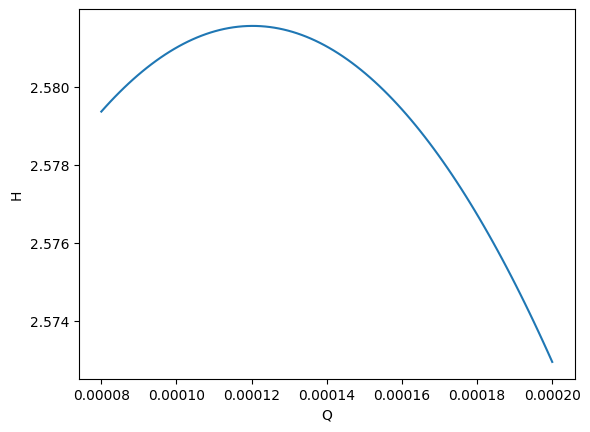

In [279]:
def f_pump_curve(q, omega, pump_coeffs):
    return (
        1 * pump_coeffs[0] * (q) ** 2
        + 1 * pump_coeffs[1] * (q) * (omega)
        + 1 * pump_coeffs[2] * (omega) ** 2
        # +2
    )


q_list = np.linspace(0.8 * q_mean, 2 * q_mean, 100)

plt.plot(q_list, [f_pump_curve(q, omega_mean, pump_coeffs_si) for q in q_list])
plt.xlabel("Q")
plt.ylabel("H")

In [280]:
F_p_0 = (
    np.linalg.inv(np.diagflat(L))
    @ np.diagflat(R)
    @ np.full((1, pipe_number), np.abs(q_mean) * q_mean)[0]
).reshape(pipe_number, 1)
F_p_0

array([[1.32039656e-08],
       [1.32039656e-08],
       [1.32039656e-04],
       [1.32039656e-08],
       [1.32039656e-08],
       [1.32039656e-08]])

In [281]:
F_e_0 = -(  # -
    pump_coeffs_si[0] * (q_mean) ** 2
    + pump_coeffs_si[1] * (q_mean) * (omega_mean)
    + pump_coeffs_si[2] * (omega_mean) ** 2
    # 2
)
F_e_0

-2.580999087518134

In [282]:
F_0 = np.block(
    [
        [F_p_0],
        [F_e_0],
        [np.zeros(shape=(internal_node_number, 1))],
        [np.zeros(shape=(element_number, 1))],
    ]
)
F_0

array([[ 1.32039656e-08],
       [ 1.32039656e-08],
       [ 1.32039656e-04],
       [ 1.32039656e-08],
       [ 1.32039656e-08],
       [ 1.32039656e-08],
       [-2.58099909e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00]])

## x_0

In [283]:
x_0 = np.block(
    [
        [
            0.0005 * np.ones((pipe_number, 1))
        ],  # q_mean 0.001497438790850693 # worked with 0.0008826048766538281
        [
            0.0005 * np.ones((element_number, 1))
        ],  # q_mean 0.001497438790850693 # worked with 0.0008826048766538281
        [h_I_0],
        [z_0],
    ]
)
x_0

array([[5.00000000e-04],
       [5.00000000e-04],
       [5.00000000e-04],
       [5.00000000e-04],
       [5.00000000e-04],
       [5.00000000e-04],
       [5.00000000e-04],
       [9.43282863e-01],
       [3.52428195e+00],
       [3.32424387e+00],
       [1.20000000e+00],
       [8.75000000e-01],
       [8.75000000e-01],
       [3.64101792e+01]])

In [284]:
(x_0[4] - x_0[3])[0]

0.0

In [285]:
E = np.block(
    [
        [
            np.eye(pipe_number),
            np.zeros((pipe_number, element_number)),
            np.zeros((pipe_number, internal_node_number)),
            np.zeros((pipe_number, element_number)),
        ],
        [
            np.zeros((element_number, pipe_number)),
            np.zeros((element_number, element_number)),
            np.zeros((element_number, internal_node_number)),
            np.zeros((element_number, element_number)),
        ],
        [
            np.zeros((internal_node_number, pipe_number)),
            np.zeros((internal_node_number, element_number)),
            np.eye(internal_node_number),
            np.zeros((internal_node_number, element_number)),
        ],
        [
            np.zeros((element_number, pipe_number)),
            np.zeros((element_number, element_number)),
            np.zeros((element_number, internal_node_number)),
            np.eye(element_number),
        ],
    ]
)

In [286]:
alg_vars = np.isclose(np.linalg.norm(E, axis=1), 0.0)

In [287]:
rhs_0 = A @ x_0 - F_0 + B @ u_0
x_dot_0 = np.zeros_like(x_0)
diff_rows = ~alg_vars
E_mod = E[diff_rows]
E_dyn = E_mod[:, diff_rows]
x_dot_0[diff_rows] = np.linalg.solve(E_dyn, rhs_0[diff_rows])
x_dot_0[alg_vars] = 0.0

In [288]:
rhs_0

array([[ 0.00000000e+00],
       [ 6.93428038e-05],
       [ 3.55048599e-03],
       [ 3.31404609e-04],
       [-1.32039656e-08],
       [-3.38307026e-04],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 0.00000000e+00]])

In [289]:
A_mod = A[diff_rows]
A_dyn = A_mod[:, diff_rows]
B_dyn = B[diff_rows]

## DAE system definition

### Dyanmic state variables

In [290]:
# Dynamic state
flow_pump_suction_pipe = ca.MX.sym("flow_pump_suction_pipe")
flow_tank_feeding_pipe = ca.MX.sym("flow_tank_feeding_pipe")
flow_tank_connecting_pipe = ca.MX.sym("flow_tank_connecting_pipe")
flow_tank_outlet_pipe = ca.MX.sym("flow_tank_outlet_pipe")
flow_valve_pipe = ca.MX.sym("flow_valve_pipe")
flow_consumer_outlet_pipe = ca.MX.sym("flow_consumer_outlet_pipe")
head_pump_inlet = ca.MX.sym("head_pump_inlet")
head_pump_outlet = ca.MX.sym("head_pump_outlet")
head_tank_inlet = ca.MX.sym("head_tank_inlet")
head_tank_outlet = ca.MX.sym("head_tank_outlet")
head_valve_inlet = ca.MX.sym("head_valve_inlet")
head_valve_outlet = ca.MX.sym("head_valve_outlet")
pump_speed = ca.MX.sym("pump_speed")
x = ca.vertcat(
    flow_pump_suction_pipe,
    flow_tank_feeding_pipe,
    flow_tank_connecting_pipe,
    flow_tank_outlet_pipe,
    flow_valve_pipe,
    flow_consumer_outlet_pipe,
    head_pump_inlet,
    head_pump_outlet,
    head_tank_inlet,
    head_tank_outlet,
    head_valve_inlet,
    head_valve_outlet,
    pump_speed,
)

x_names = [
    "flow_pump_suction_pipe",
    "flow_tank_feeding_pipe",
    "flow_tank_connecting_pipe",
    "flow_tank_outlet_pipe",
    "flow_valve_pipe",
    "flow_consumer_outlet_pipe",
    "head_pump_inlet",
    "head_pump_outlet",
    "head_tank_inlet",
    "head_tank_outlet",
    "head_valve_inlet",
    "head_valve_outlet",
    "pump_speed",
]

# x_dot_sym = ca.MX.sym("x_dot_sym", x.shape[0])
# x_dot = ca.vertcat(x_dot_sym)

In [291]:
lb_flow = np.full((pipe_number), 0)
ub_flow = np.full((pipe_number), 5 * q_mean)
lb_head = np.full((internal_node_number), 0)
ub_head = np.full((internal_node_number), 5 * reservoir_total_head)  # orig: 1*
lb_pump = np.full((element_number), 0)  # orig: 0
ub_pump = np.full((element_number), 75)  # orig: 1
lbx = ca.vertcat(*lb_flow, *lb_head, *lb_pump)
ubx = ca.vertcat(*ub_flow, *ub_head, *ub_pump)

### Algebraic state variables

In [292]:
# Algebraic state
flow_pump = ca.MX.sym("flow_pump")
alg_state = ca.vertcat(flow_pump)
lb_flow_pump = np.full(element_number, 0)
ub_flow_pump = np.full(element_number, 5 * q_mean)
lb_alg_state = ca.vertcat(lb_flow_pump)
up_alg_state = ca.vertcat(ub_flow_pump)

### Control inputs

In [293]:
# Control inputs
reservoir_head_1 = ca.MX.sym("reservoir_head_1")
reservoir_head_2 = ca.MX.sym("reservoir_head_2")
demand_pump_inlet = ca.MX.sym("demand_pump_inlet")
demand_pump_outlet = ca.MX.sym("demand_pump_outlet")
demand_tank_inlet = ca.MX.sym("demand_tank_inlet")
demand_tank_outlet = ca.MX.sym("demand_tank_outlet")
demand_valve_inlet = ca.MX.sym("demand_valve_inlet")
demand_valve_outlet = ca.MX.sym("demand_valve_outlet")
pump_input = ca.MX.sym("pump_input")
u = ca.vertcat(
    reservoir_head_1,
    reservoir_head_2,
    demand_pump_inlet,
    demand_pump_outlet,
    demand_tank_inlet,
    demand_tank_outlet,
    demand_valve_inlet,
    demand_valve_outlet,
    pump_input,
)

In [294]:
lb_reservoir_head = np.full(reservoir_number, 0.8 * reservoir_total_head)
lb_demand = np.full(internal_node_number, 0)
lb_pump_input = np.full(element_number, 0)
lbu = ca.vertcat(*lb_reservoir_head, *lb_demand, *lb_pump_input)

ub_reservoir_head = np.full(reservoir_number, 1.2 * reservoir_total_head)
ub_demand = np.full(internal_node_number, 5 * q_mean)
ub_pump_input = np.full(element_number, 74)
ubu = ca.vertcat(*ub_reservoir_head, *ub_demand, *ub_pump_input)

In [295]:
pipe_flows = ca.vertcat(
    flow_pump_suction_pipe,
    flow_tank_feeding_pipe,
    flow_tank_connecting_pipe,
    flow_tank_outlet_pipe,
    flow_valve_pipe,
    flow_consumer_outlet_pipe,
)

In [296]:
L_inv_times_R = np.linalg.inv(np.diagflat(L)) @ np.diagflat(R)

### Nonlinear terms

In [297]:
# Non-linear termns
F_p_flow_pump_suction_pipe = (
    L_inv_times_R[0, 0] * ca.fabs(flow_pump_suction_pipe) * flow_pump_suction_pipe
)
F_p_flow_tank_feeding_pipe = (
    L_inv_times_R[1, 1] * ca.fabs(flow_tank_feeding_pipe) * flow_tank_feeding_pipe
)
F_p_flow_tank_connecting_pipe = (
    L_inv_times_R[2, 2] * ca.fabs(flow_tank_connecting_pipe) * flow_tank_connecting_pipe
)
F_p_flow_tank_outlet_pipe = (
    L_inv_times_R[3, 3] * ca.fabs(flow_tank_outlet_pipe) * flow_tank_outlet_pipe
)
F_p_flow_valve_pipe = L_inv_times_R[4, 4] * ca.fabs(flow_valve_pipe) * flow_valve_pipe
F_p_flow_consumer_outlet_pipe = (
    L_inv_times_R[5, 5] * ca.fabs(flow_consumer_outlet_pipe) * flow_consumer_outlet_pipe
)
F_q_pump = G @ A_I_e @ alg_state  # orig: plus
F_p = ca.vertcat(
    F_p_flow_pump_suction_pipe,
    F_p_flow_tank_feeding_pipe,
    F_p_flow_tank_connecting_pipe,
    F_p_flow_tank_outlet_pipe,
    F_p_flow_valve_pipe,
    F_p_flow_consumer_outlet_pipe,
    F_q_pump,
    *([0] * element_number),
)

In [298]:
(
    pump_coeffs_si[0] * (q_mean) ** 2
    + pump_coeffs_si[1] * (q_mean) * (omega_mean)
    + pump_coeffs_si[2] * (omega_mean) ** 2
)

2.580999087518134

### Algebraic equation

In [299]:
# Equations
alg_eq = -(  # -
    pump_coeffs_si[0] * (flow_pump) ** 2
    + pump_coeffs_si[1] * (flow_pump) * (pump_speed)
    + pump_coeffs_si[2] * (pump_speed) ** 2
    # 2
) + (head_pump_outlet - head_pump_inlet)  # orig: +()

### State equation

In [300]:
x_dot = A_dyn @ x + B_dyn @ u - F_p
x_dot

MX(((mac(
[[0, 0, 0, 0, 0, 0, -0.000770476, 0, 0, 0, 0, 0, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0.000346714, -0.000346714, 0, 0, 0, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0, 0.00173357, -0.00173357, 0, 0, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00101975, -0.00101975, 0, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0173357, -0.0173357, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00495306, 0], 
 [2.45466e+08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
 [0, -1.13107e+08, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
 [0, 0.002, -0.002, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
 [0, 0, 66.6666, -66.6666, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
 [0, 0, 0, 3.20469e+08, -3.20469e+08, 0, 0, 0, 0, 0, 0, 0, 0], 
 [0, 0, 0, 0, 1.28188e+09, -1.28188e+09, 0, 0, 0, 0, 0, 0, 0], 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.3]],vertcat(flow_pump_suction_pipe, flow_tank_feeding_pipe, flow_tank_connecting_pipe, flow_tank_outlet_pipe, flow_valve_pipe, flow_consumer_outlet_pipe, head_pump_inlet, head_pump_outlet, head_tank_inlet, head_tank_outlet, head_valve_inlet, head_valve

## Simulation with DAE Solver

In [301]:
dt = 1e-4
t = np.arange(0, 25, dt)
t0 = 0

dae = {"x": x, "z": alg_state, "p": u, "ode": x_dot, "alg": alg_eq}

opts = {
    "tf": 1e-4,  # time step for each integrator call
    #     "abstol": 1e-8,
    #     "reltol": 1e-8,
}

Fint = ca.integrator("Fint", "idas", dae, t0, dt, {"calc_ic": True})  #

# initial conditions
x0 = ca.DM(x_0[diff_rows])
z0 = ca.DM(x_0[alg_vars])

u0 = ca.DM(u_0)
u0 = []
tc = 15
LL = 1  # logistic function coeff
k = 10
for tt in t:
    # if tt < tc:
    #     u0.append(ca.DM(u_0))
    # else:
    #     u0.append(ca.DM((u_0 * np.array([1, 1, 1, 1, 1]).reshape(5, 1)).flatten()))
    u0.append(
        ca.DM(
            (
                u_0
                * np.array(
                    [
                        1,
                        1,
                        1,
                        1,
                        1,
                        1,
                        1,
                        1,
                        1,
                    ]  # + 0.2 * LL / (1 + np.e ** (-k * (tt - tc)))]
                ).reshape(9, 1)
            ).flatten()
        )
    )


x_vals = np.zeros((len(t), x0.numel()))
x_vals[0, :] = np.array(x0.T).ravel()
xt = x0

z_vals = np.zeros((len(t), z0.numel()))
z_vals[0, :] = np.array(z0.T).ravel()
zt = z0

res = Fint(x0=xt, z0=zt, p=u0[0])

In [302]:
for i, tt in enumerate(t):
    res = Fint(x0=xt, z0=zt, p=u0[i])
    xt = res["xf"]
    zt = res["zf"]
    x_vals[i, :] = np.array(xt.T).ravel()
    z_vals[i, :] = np.array(zt.T).ravel()

## Results

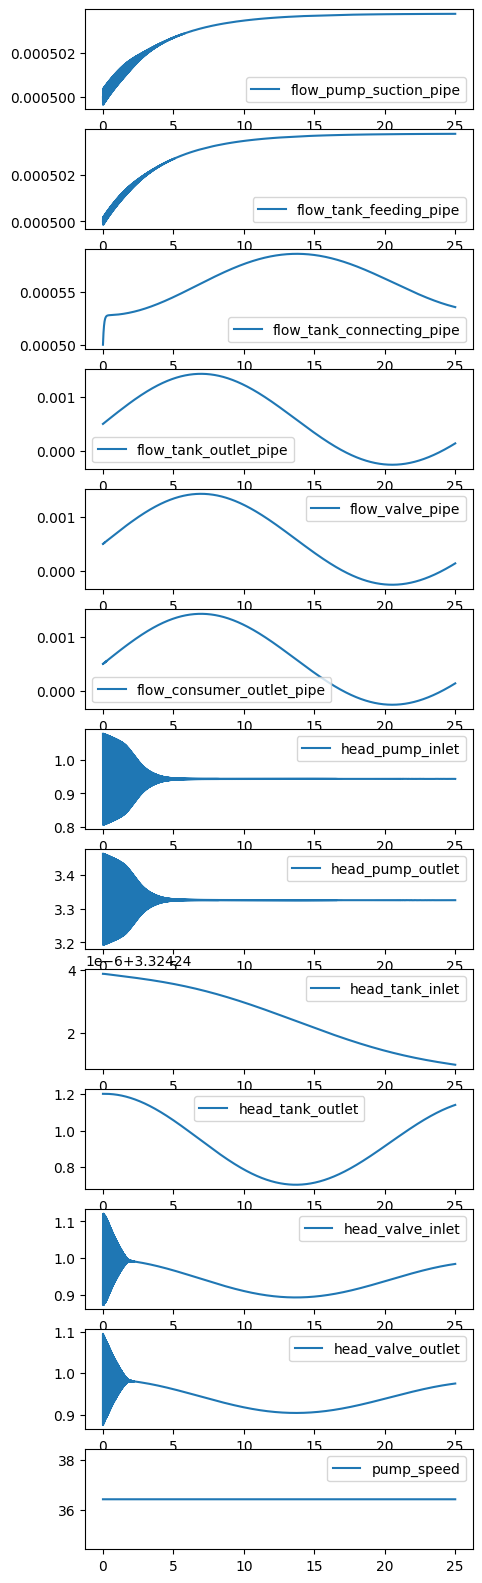

In [303]:
fig, axs = plt.subplots(len(x_0) - 1, figsize=(5, 20))
n = 1
for i in range(len(x_0) - 1):
    axs[i].plot(t[::n], x_vals[::n, i], label=x_names[i])  # plotting every nth point
    axs[i].legend()

# axs[0].set_ylim((-0.0005, 0.0005))
# axs[1].set_ylim((-0.0005, 0.0005))

In [304]:
G

array([[2.45465653e+08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.13106722e+08, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.00000000e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.66666459e+01,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.20469046e+08, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.28187619e+09]])

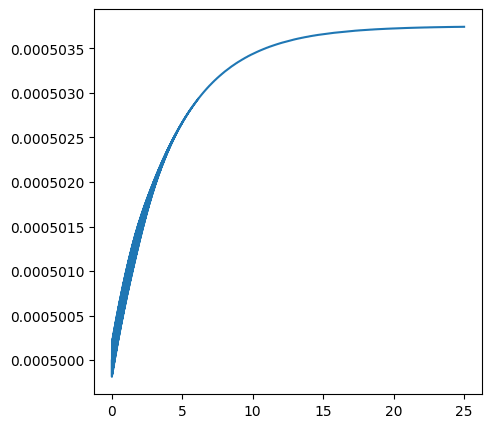

In [305]:
fig, axs = plt.subplots(len(x_0[alg_vars]), figsize=(5, 5))

for i in range(len(x_0[alg_vars])):
    axs.plot(t, z_vals[:, i])

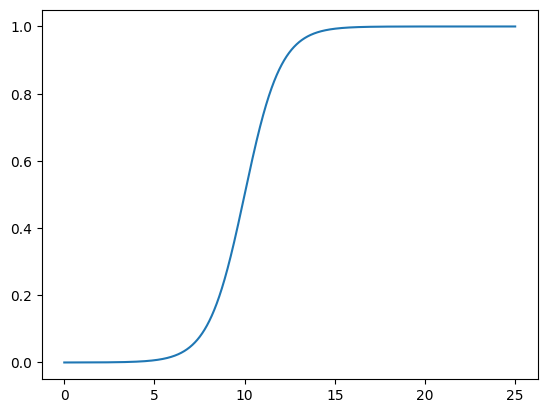

In [306]:
ttt = np.arange(0, 25, 1e-4)

L = 1
k = 1
t0 = 10
plt.plot(ttt, [L / (1 + np.e ** (-k * (t - t0))) for t in ttt])

In [307]:
from scipy.integrate import solve_ivp

KeyboardInterrupt: 

In [ ]:
# Parameters
a = 0.3
t_eval = np.arange(0, 50, dt)


k = 20


# v(t) piecewise definition
def v_of_t(t):
    return 5 * (1 + 0.3 * LL / (1 + np.e ** (-k * (t - tc))))


# ODE
def dsdt(t, s):
    return a * (v_of_t(t) - s)


# Initial condition
s0 = [5.0]

# Solve
sol = solve_ivp(dsdt, (t_eval[0], t_eval[-1]), s0, t_eval=t_eval)

# Plot
plt.plot(sol.t, sol.y[0], label="s(t)")
plt.axvline(10, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("t")
plt.ylabel("s")
plt.legend()
plt.show()

### initial conditions tank flow

In [ ]:
aa = pump_coeffs_si[0] - R[0][0] - R[1][0]
bb = pump_coeffs_si[1] * omega_mean
cc = pump_coeffs_si[2] * omega_mean**2 - (
    internal_nodes["tank_inlet"]["elevation"]
    - internal_nodes["pump_inlet"]["elevation"]
)

In [ ]:
det = bb**2 - 4 * aa * cc
r_1 = (-bb + np.sqrt(det)) / (2 * aa)
r_2 = (-bb - np.sqrt(det)) / (2 * aa)

In [ ]:
r_1

In [ ]:
r_2